In [17]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / "Data/한강공원 주차장 일별 이용 현황.csv").exists() and (project_root.parent / "Data/한강공원 주차장 일별 이용 현황.csv").exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [18]:
parking_raw_path = project_root / "Data/한강공원 주차장 일별 이용 현황.csv"
weather_path = project_root / "outputs/yeouido_weather_daily.csv"
traffic_note_path = project_root / "Note/analystics_traffic_new_23.ipynb"
subway_note_path = project_root / "Note/analystics_sub_new_23.ipynb"

parking_raw_df = pd.read_csv(parking_raw_path, encoding="cp949")
parking_raw_df["날짜"] = pd.to_datetime(parking_raw_df["날짜"])

parking_2023_df = parking_raw_df[
    (parking_raw_df["날짜"].dt.year == 2023)
    & (parking_raw_df["주차장명"].astype(str).str.contains("여의도", na=False))
].copy()

parking_daily_df = parking_2023_df.groupby("날짜", as_index=False).agg(
    parking_usage=("주차대수", "sum"),
    usage_time=("이용시간", "sum"),
    source_rows=("주차장명", "size"),
    parking_lot_count=("주차장명", pd.Series.nunique),
)

weather_daily_df = pd.read_csv(weather_path)
weather_daily_df["date"] = pd.to_datetime(weather_daily_df["date"])
weather_2023 = weather_daily_df[weather_daily_df["date"].dt.year == 2023].copy()

weather_2023["weather_group"] = weather_2023.apply(
    lambda row: "snow"
    if row["snowfall_sum"] > 0
    else (
        "rainy"
        if row["precipitation_sum"] > 0
        else ("clear" if row["weather_category"] == "clear" else "cloudy")
    ),
    axis=1,
)


In [19]:
# Same weekday rule used in analystics_traffic_new_23.ipynb and analystics_sub_new_23.ipynb.
merged_df = parking_daily_df.merge(
    weather_2023[["date", "weather_group", "weather_label_ko"]],
    left_on="날짜",
    right_on="date",
    how="inner",
)
merged_df["날짜타입"] = merged_df["날짜"].dt.weekday.map(lambda x: "주말" if x >= 5 else "평일")
weekday_df = merged_df[merged_df["날짜타입"] == "평일"].copy()

weather_order = ["clear", "cloudy", "snow", "rainy"]
weather_label_map = {
    "clear": "clear",
    "cloudy": "cloudy",
    "snow": "snow",
    "rainy": "rainy",
}

weekday_summary_df = (
    weekday_df.groupby("weather_group", as_index=False)
    .agg(days=("parking_usage", "size"), median_usage=("parking_usage", "median"))
)
weekday_summary_df["weather_group"] = pd.Categorical(
    weekday_summary_df["weather_group"], categories=weather_order, ordered=True
)
weekday_summary_df = weekday_summary_df.sort_values("weather_group").reset_index(drop=True)
weekday_summary_df["weather_label"] = weekday_summary_df["weather_group"].map(weather_label_map)

display(weekday_summary_df)


,weather_group,days,median_usage,weather_label
0,clear,22,3827.5,clear
1,cloudy,118,4938.5,cloudy
2,snow,8,3315.0,snow
3,rainy,112,4424.5,rainy


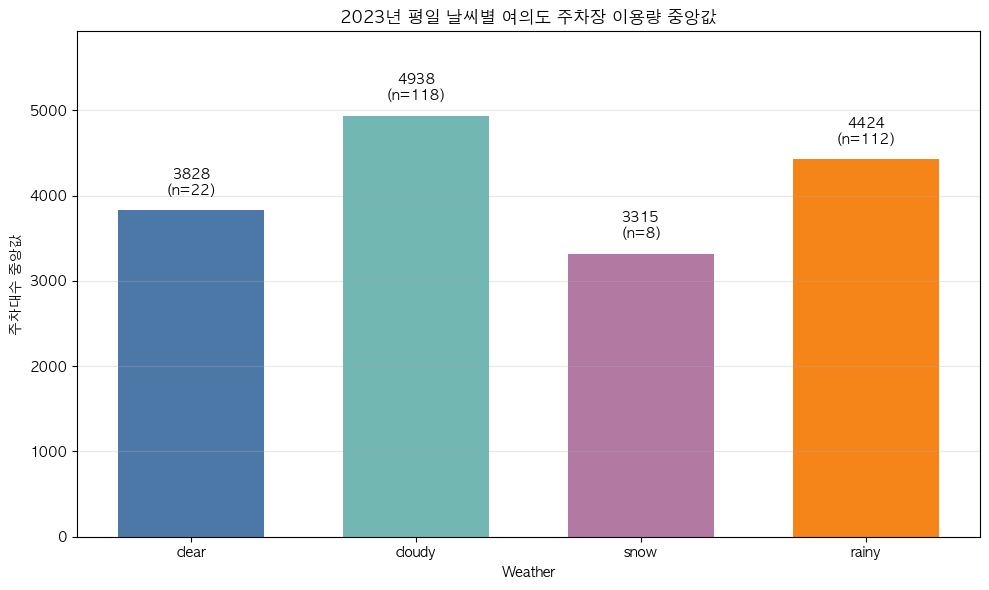

In [20]:
plot_df = weekday_summary_df.copy()
bar_colors = {
    "clear": "#4C78A8",
    "cloudy": "#72B7B2",
    "snow": "#B279A2",
    "rainy": "#F58518",
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    plot_df["weather_label"],
    plot_df["median_usage"],
    color=[bar_colors[item] for item in plot_df["weather_group"]],
    width=0.65,
)

max_usage = plot_df["median_usage"].max() if not plot_df.empty else 0
label_offset = max_usage * 0.03
for idx, row in plot_df.iterrows():
    label_text = f"{row['median_usage']:.0f}" + chr(10) + f"(n={int(row['days'])})"
    ax.text(
        idx,
        row["median_usage"] + label_offset,
        label_text,
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylim(0, max_usage * 1.2 if max_usage else 1)
ax.set_title("2023년 평일 날씨별 여의도 주차장 이용량 중앙값")
ax.set_xlabel("Weather")
ax.set_ylabel("주차대수 중앙값")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
comparison_rows = []
for i, base_row in weekday_summary_df.iterrows():
    for j, compare_row in weekday_summary_df.iterrows():
        if j <= i:
            continue
        base_value = base_row["median_usage"]
        compare_value = compare_row["median_usage"]
        diff_value = compare_value - base_value
        diff_pct = (diff_value / base_value * 100) if base_value else pd.NA
        comparison_rows.append(
            {
                "날씨1": base_row["weather_label"],
                "날씨2": compare_row["weather_label"],
                "중앙값1": base_value,
                "중앙값2": compare_value,
                "차이(날씨2-날씨1)": diff_value,
                "증감률(%)": diff_pct,
            }
        )

weather_diff_df = pd.DataFrame(comparison_rows)
display(weather_diff_df)


,날씨1,날씨2,중앙값1,중앙값2,차이(날씨2-날씨1),증감률(%)
0,clear,cloudy,3827.5,4938.5,1111.0,29.026780
1,clear,snow,3827.5,3315.0,-512.5,-13.389941
2,clear,rainy,3827.5,4424.5,597.0,15.597649
3,cloudy,snow,4938.5,3315.0,-1623.5,-32.874355
4,cloudy,rainy,4938.5,4424.5,-514.0,-10.408019
5,snow,rainy,3315.0,4424.5,1109.5,33.469080
